I. Data Cleaning and Processing of 'games' data

In [45]:
import pandas as pd
import numpy as np
import re
import os

# 1. LOAD DATA 
# Note: Ensure 'games.csv' is in the same folder as this script or provide the full path
file_path = r"E:\Labmentix Internship\Game Sales\games.csv"
df = pd.read_csv(file_path, encoding='latin-1')

# 2. STRUCTURAL CLEANING
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)
df = df.drop_duplicates()

# 3. CONVERT METRICS (Handling 'K' for Tableau Measures)
def convert_k_to_int(val):
    if pd.isna(val): return 0
    val = str(val).strip().upper()
    if 'K' in val:
        try:
            return int(float(val.replace('K', '')) * 1000)
        except:
            return 0
    clean_val = re.sub(r'[^\d.]', '', val)
    try:
        return int(float(clean_val)) if clean_val else 0
    except:
        return 0

numeric_cols = ['Times Listed', 'Number of Reviews', 'Plays', 'Playing', 'Backlogs', 'Wishlist']
for col in numeric_cols:
    df[col] = df[col].apply(convert_k_to_int)

# 4. DATE STANDARDIZATION (SSMS DATE type)
df['Release Date'] = pd.to_datetime(df['Release Date'], errors='coerce')
valid_dates = df['Release Date'].dropna().sort_values()
if not valid_dates.empty:
    median_date = valid_dates.iloc[len(valid_dates)//2]
    df['Release Date'] = df['Release Date'].fillna(median_date)

# 5. FIXING THE "BLANKS" (Genres & Teams)
def clean_list_logic(text):
    if pd.isna(text): return "Unknown"
    text = re.sub(r"[\[\]']", "", str(text)).strip()
    if not text or text == "" or text.isspace() or text == '""':
        return "Unknown"
    return text

df['Team'] = df['Team'].apply(clean_list_logic)
df['Genres'] = df['Genres'].apply(clean_list_logic)

# 6. TEXT SANITATION (Crucial for SSMS CSV Import)
def sanitize_for_sql(text):
    if pd.isna(text): return "Not Available"
    text = str(text)
    text = text.replace('\n', ' ').replace('\r', ' ').replace('\t', ' ')
    text = text.replace('"', "'")
    return re.sub(r'\s+', ' ', text).strip()

df['Summary'] = df['Summary'].apply(sanitize_for_sql)
df['Reviews'] = df['Reviews'].apply(sanitize_for_sql)

# 7. FILLING REMAINING NULLS
df['Rating'] = df['Rating'].fillna(df['Rating'].median())
df['Title'] = df['Title'].fillna("Unknown Title")

# 8. RENAME COLUMNS FOR SSMS (No Spaces)
df.columns = [col.replace(' ', '_') for col in df.columns]

# 9. EXPORT TO SPECIFIC DIRECTORY
# We use r"" (raw string) to handle Windows backslashes correctly
export_path = r"C:\Users\tatha\Downloads\New folder"
file_name = "games_final_for_ssms.csv"
full_output_path = os.path.join(export_path, file_name)

# Create the folder if it doesn't exist
if not os.path.exists(export_path):
    os.makedirs(export_path)

# Save the file
df.to_csv(full_output_path, index=False, encoding='utf-8-sig')

print(f"Final cleanup complete. File saved to: {full_output_path}")

Final cleanup complete. File saved to: C:\Users\tatha\Downloads\New folder\games_final_for_ssms.csv


I[a] VISUALIZATION PLOT FOR GAMES

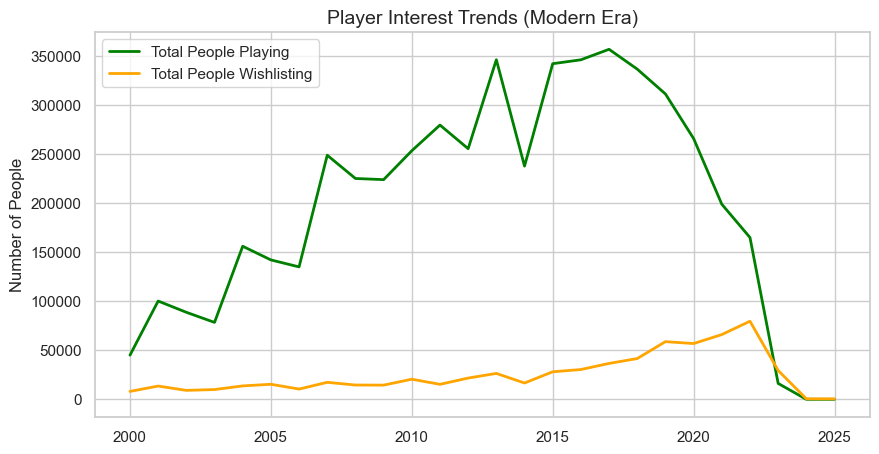

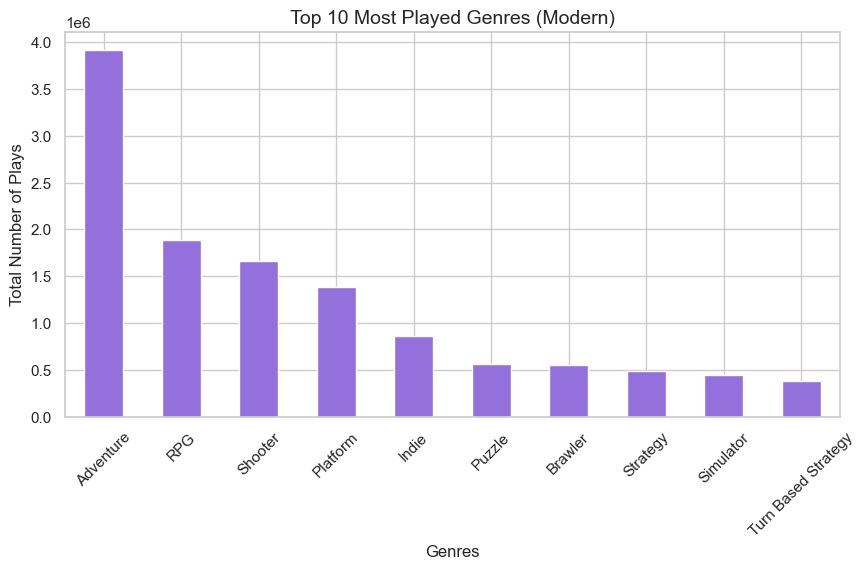

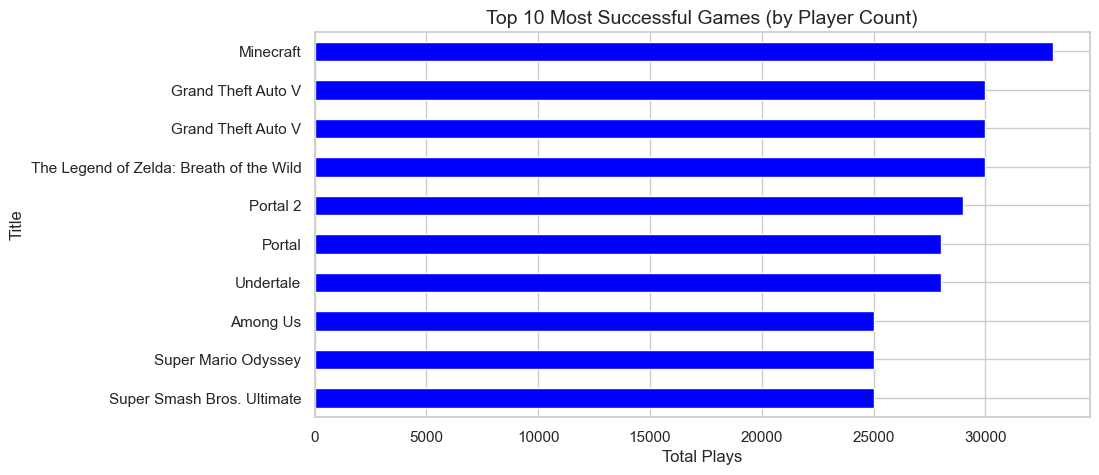

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df_games = pd.read_csv('games_final_for_ssms.csv')
df_games['Year'] = pd.to_datetime(df_games['Release_Date']).dt.year

# 1. Engagement Trend: Modern interest in games (Plays vs. Wishlists)
plt.figure(figsize=(10, 5))
modern_trend = df_games[df_games['Year'] >= 2000].groupby('Year').agg({'Plays': 'sum', 'Wishlist': 'sum'})
plt.plot(modern_trend.index, modern_trend['Plays'], label='Total People Playing', color='green', linewidth=2)
plt.plot(modern_trend.index, modern_trend['Wishlist'], label='Total People Wishlisting', color='orange', linewidth=2)
plt.title('Player Interest Trends (Modern Era)', fontsize=14)
plt.ylabel('Number of People')
plt.legend()
plt.show()

# 2. Most Played Genres: What are people actually spending time on?
plt.figure(figsize=(10, 5))
df_exp = df_games.assign(Genres=df_games['Genres'].str.split(', ')).explode('Genres')
df_exp.groupby('Genres')['Plays'].sum().sort_values(ascending=False).head(10).plot(kind='bar', color='mediumpurple')
plt.title('Top 10 Most Played Genres (Modern)', fontsize=14)
plt.ylabel('Total Number of Plays')
plt.xticks(rotation=45)
plt.show()

# 3. Key Success Factor: The 10 Most Successful Games by Player Count
plt.figure(figsize=(10, 5))
df_games.sort_values(by='Plays', ascending=False).head(10).set_index('Title')['Plays'].plot(kind='barh', color='blue').invert_yaxis()
plt.title('Top 10 Most Successful Games (by Player Count)', fontsize=14)
plt.xlabel('Total Plays')
plt.show()

II. Data cleaning and processing of 'vgsales' data

In [17]:
import pandas as pd

# Load the dataset
file_path_sales = r"E:\Labmentix Internship\Game Sales\vgsales.csv"
df_sales = pd.read_csv(file_path_sales, encoding='latin-1')

# 1. REMOVE DUPLICATES
df_sales.drop_duplicates(inplace=True)

# 2. FILLING GAPS (The "No Missing Area" Rule)
# Filling missing years with the median so they aren't excluded from timelines
df_sales['Year'] = df_sales['Year'].fillna(df_sales['Year'].median()).astype(int)

# Filling missing publishers so they appear as a category in Tableau
df_sales['Publisher'] = df_sales['Publisher'].fillna('Unknown')

# 3. TYPE INTEGRITY
# Ensure all sales are floats and handle any non-numeric errors
sales_cols = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']
for col in sales_cols:
    df_sales[col] = pd.to_numeric(df_sales[col], errors='coerce').fillna(0.0)

# 4. STANDARDIZE COLUMN NAMES
df_sales.columns = [col.replace(' ', '_') for col in df_sales.columns]

# Export to CSV
df_sales.to_csv(r"C:\Users\tatha\Downloads\New folder\vgsales_perfectly_cleaned.csv", index=False)
print("Sales dataset cleaned successfully.")

Sales dataset cleaned successfully.


II[a] VISUALIZATION PLOT FOR VG_SALES

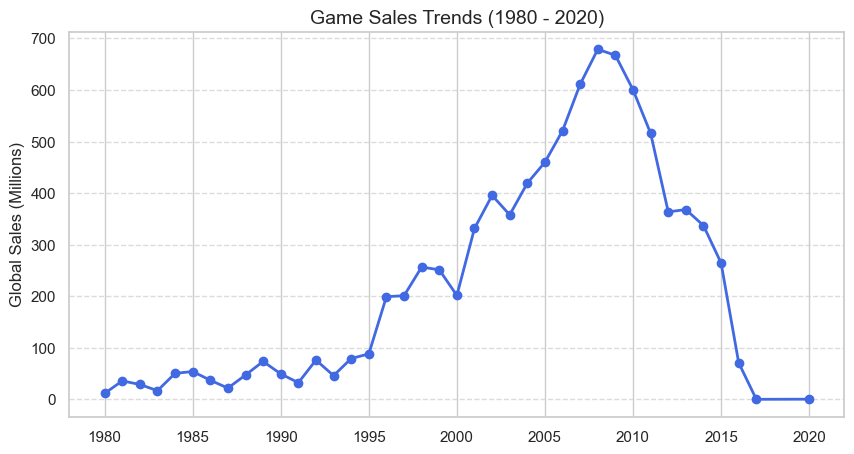

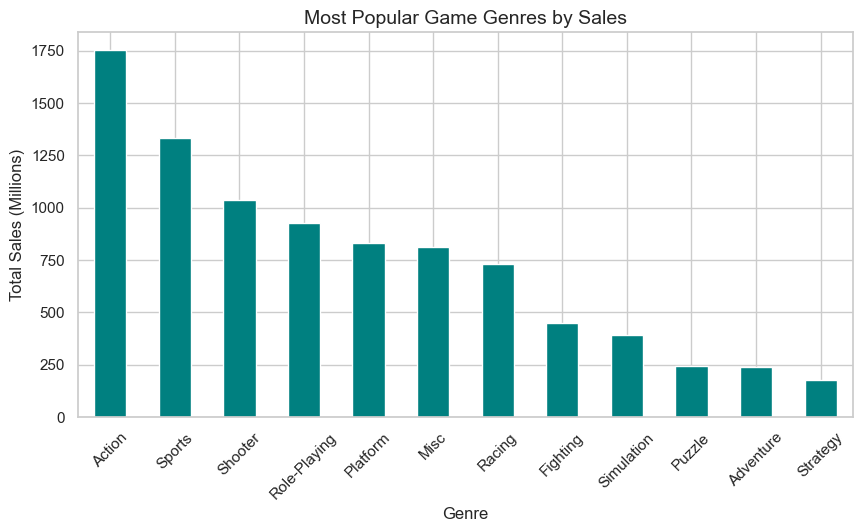

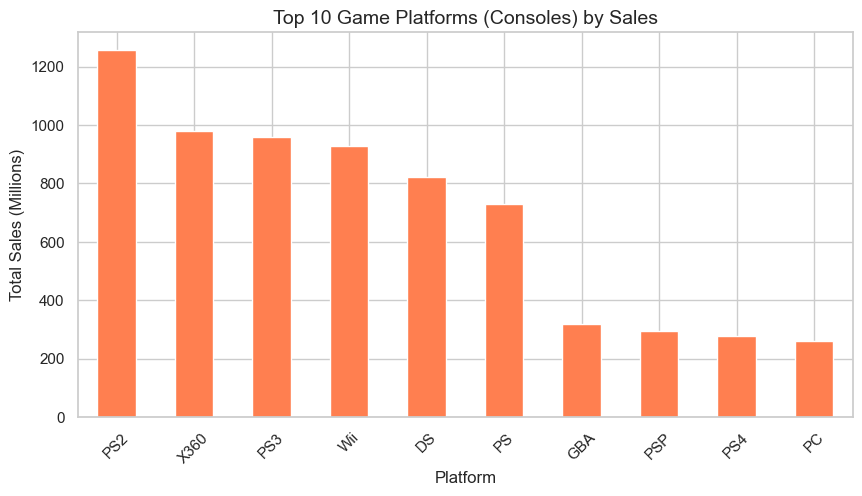

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
file_path_sales = r"E:\Labmentix Internship\Game Sales\vgsales.csv"
df_sales = pd.read_csv(file_path_sales, encoding='latin-1')

# 1. Sales Trend: How the industry grew over time
plt.figure(figsize=(10, 5))
sales_trend = df_sales.groupby('Year')['Global_Sales'].sum().reset_index()
plt.plot(sales_trend['Year'], sales_trend['Global_Sales'], color='royalblue', linewidth=2, marker='o')
plt.title('Game Sales Trends (1980 - 2020)', fontsize=14)
plt.ylabel('Global Sales (Millions)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 2. Genre Popularity: Which types of games sell the most?
plt.figure(figsize=(10, 5))
df_sales.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False).plot(kind='bar', color='teal')
plt.title('Most Popular Game Genres by Sales', fontsize=14)
plt.ylabel('Total Sales (Millions)')
plt.xticks(rotation=45)
plt.show()

# 3. Platform Success: Which consoles have the most game sales?
plt.figure(figsize=(10, 5))
df_sales.groupby('Platform')['Global_Sales'].sum().sort_values(ascending=False).head(10).plot(kind='bar', color='coral')
plt.title('Top 10 Game Platforms (Consoles) by Sales', fontsize=14)
plt.ylabel('Total Sales (Millions)')
plt.xticks(rotation=45)
plt.show()

III. JOINING THE TWO DATASETS

In [36]:
# 2. Normalize titles to ensure perfect matching
df_sales['Name_Clean'] = df_sales['Name'].str.lower().str.strip()
df_games_unique['Title_Clean'] = df_games_unique['Title'].str.lower().str.strip()

# 3. Perform an Inner Join 
# This ensures no "blanks" - only games present in both datasets are kept.
merged_df = pd.merge(df_sales, df_games_unique, left_on='Name_Clean', right_on='Title_Clean', how='inner')

# 4. Clean up columns for Tableau
# Keep 'Year' from vgsales as 'Release_Year', drop redundant matching columns
merged_df.rename(columns={'Year_x': 'Release_Year'}, inplace=True)
merged_df.drop(['Name_Clean', 'Title_Clean', 'Year_y', 'Title'], axis=1, inplace=True)

# 5. Final check for nulls and save
merged_df = merged_df.dropna()
merged_df.to_csv(r'C:\Users\tatha\Downloads\New folder\merged_game_data_for_tableau.csv', index=False)

print("Join complete. Final dataset contains", merged_df.shape[0], "rows and", merged_df.shape[1], "columns.")

Join complete. Final dataset contains 997 rows and 23 columns. File saved to: C:\Users\tatha\Downloads\New folder\merged_game_data_for_tableau.csv
